In [1]:
# PYTHON TASK 2: GEOSPATIAL RETURN MAPPING
import pandas as pd
import matplotlib.pyplot as plt


file_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\Sales Transaction.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (536350, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [2]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB

Columns:
['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']


In [3]:
df = df.dropna(subset=["Country"]).copy()

df["Country"] = df["Country"].astype(str).str.strip()

df = df[df["Country"] != ""].copy()

print("Rows after cleaning Country:", len(df))

Rows after cleaning Country: 536350


In [4]:
df["Is_Returned"] = (
    df["TransactionNo"]
    .astype(str)
    .str.startswith("C")
    .astype(int)
)

df[["TransactionNo", "Country", "Is_Returned"]].head(10)

,TransactionNo,Country,Is_Returned
0,581482,United Kingdom,0
1,581475,United Kingdom,0
2,581475,United Kingdom,0
3,581475,United Kingdom,0
4,581475,United Kingdom,0
5,581475,United Kingdom,0
6,581475,United Kingdom,0
7,581475,United Kingdom,0
8,581475,United Kingdom,0
9,581475,United Kingdom,0


In [5]:
overall_return_rate = df["Is_Returned"].mean() * 100

print(
    "Overall Return Rate:",
    round(overall_return_rate, 2),
    "%"
)

Overall Return Rate: 1.6 %


In [6]:
country_analysis = (
    df.groupby("Country")
    .agg(
        Total_Transactions=("TransactionNo", "count"),
        Returned_Transactions=("Is_Returned", "sum"),
        Return_Probability=("Is_Returned", "mean")
    )
    .reset_index()
)

country_analysis["Return_Rate_Percentage"] = (
    country_analysis["Return_Probability"] * 100
)

country_analysis = country_analysis.sort_values(
    "Return_Rate_Percentage",
    ascending=False
)

country_analysis.head(20)

,Country,Total_Transactions,Returned_Transactions,Return_Probability,Return_Rate_Percentage
34,USA,379,112,0.295515,29.551451
8,Czech Republic,28,4,0.142857,14.285714
29,Saudi Arabia,10,1,0.100000,10.000000
23,Malta,149,14,0.093960,9.395973
20,Japan,371,34,0.091644,9.164420
19,Italy,661,37,0.055976,5.597579
0,Australia,1704,73,0.042840,4.284038
14,Germany,10675,435,0.040749,4.074941
10,EIRE,8048,241,0.029945,2.994533
32,Sweden,417,9,0.021583,2.158273


In [7]:
minimum_transactions = 100

reliable_country_analysis = country_analysis[
    country_analysis["Total_Transactions"] >= minimum_transactions
].copy()

reliable_country_analysis = reliable_country_analysis.sort_values(
    "Return_Rate_Percentage",
    ascending=False
)

reliable_country_analysis.head(20)

,Country,Total_Transactions,Returned_Transactions,Return_Probability,Return_Rate_Percentage
34,USA,379,112,0.295515,29.551451
23,Malta,149,14,0.093960,9.395973
20,Japan,371,34,0.091644,9.164420
19,Italy,661,37,0.055976,5.597579
0,Australia,1704,73,0.042840,4.284038
14,Germany,10675,435,0.040749,4.074941
10,EIRE,8048,241,0.029945,2.994533
32,Sweden,417,9,0.021583,2.158273
9,Denmark,416,8,0.019231,1.923077
31,Spain,2430,44,0.018107,1.810700


In [8]:
high_return_countries = reliable_country_analysis[
    reliable_country_analysis["Return_Rate_Percentage"]
    > overall_return_rate
].copy()

print("Countries Above Overall Return Rate:")

high_return_countries

Countries Above Overall Return Rate:


,Country,Total_Transactions,Returned_Transactions,Return_Probability,Return_Rate_Percentage
34,USA,379,112,0.295515,29.551451
23,Malta,149,14,0.093960,9.395973
20,Japan,371,34,0.091644,9.164420
19,Italy,661,37,0.055976,5.597579
0,Australia,1704,73,0.042840,4.284038
14,Germany,10675,435,0.040749,4.074941
10,EIRE,8048,241,0.029945,2.994533
32,Sweden,417,9,0.021583,2.158273
9,Denmark,416,8,0.019231,1.923077
31,Spain,2430,44,0.018107,1.810700


In [9]:
top_10_return_countries = reliable_country_analysis.head(10)

top_10_return_countries

,Country,Total_Transactions,Returned_Transactions,Return_Probability,Return_Rate_Percentage
34,USA,379,112,0.295515,29.551451
23,Malta,149,14,0.093960,9.395973
20,Japan,371,34,0.091644,9.164420
19,Italy,661,37,0.055976,5.597579
0,Australia,1704,73,0.042840,4.284038
14,Germany,10675,435,0.040749,4.074941
10,EIRE,8048,241,0.029945,2.994533
32,Sweden,417,9,0.021583,2.158273
9,Denmark,416,8,0.019231,1.923077
31,Spain,2430,44,0.018107,1.810700


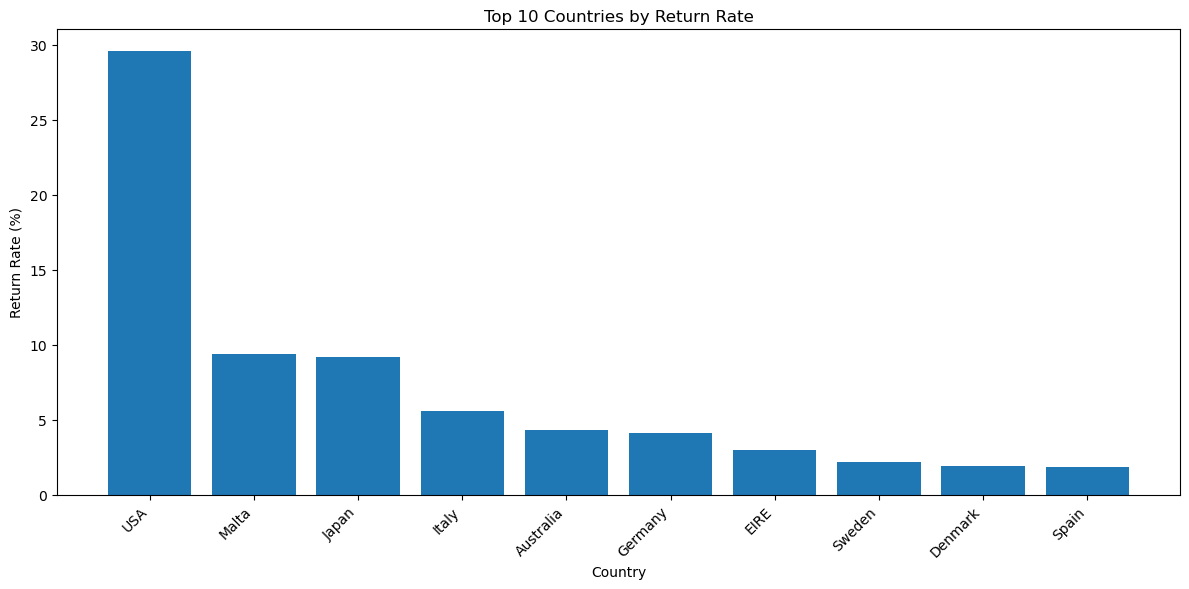

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_return_countries["Country"],
    top_10_return_countries["Return_Rate_Percentage"]
)

plt.xlabel("Country")

plt.ylabel("Return Rate (%)")

plt.title("Top 10 Countries by Return Rate")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

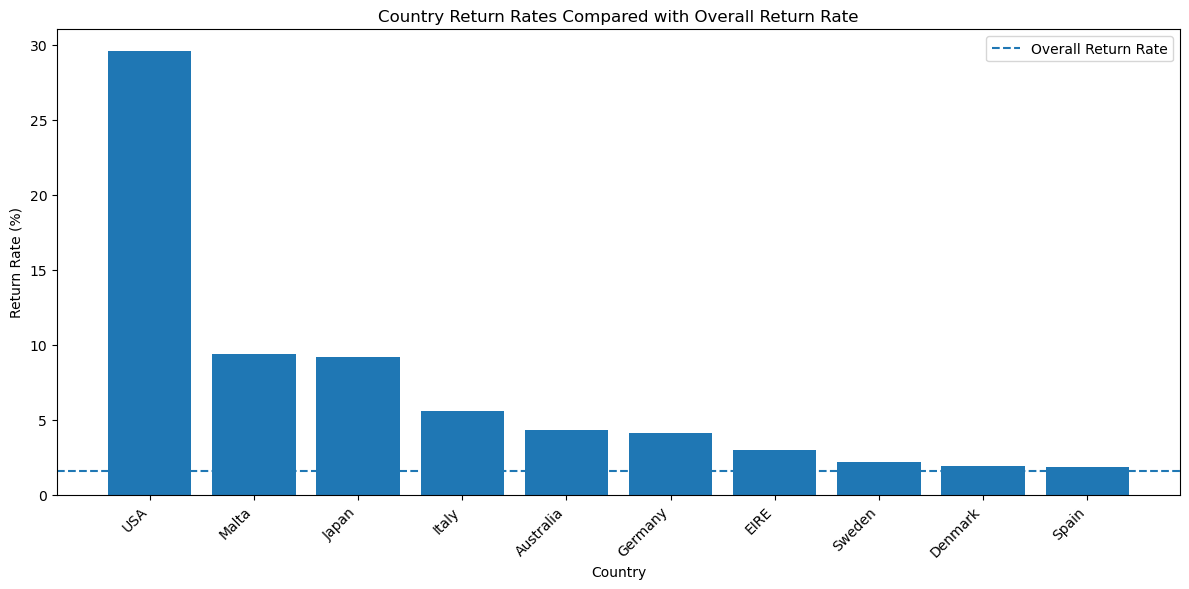

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_return_countries["Country"],
    top_10_return_countries["Return_Rate_Percentage"]
)

plt.axhline(
    y=overall_return_rate,
    linestyle="--",
    label="Overall Return Rate"
)

plt.xlabel("Country")

plt.ylabel("Return Rate (%)")

plt.title("Country Return Rates Compared with Overall Return Rate")

plt.xticks(rotation=45, ha="right")

plt.legend()

plt.tight_layout()

plt.show()

In [12]:
df["Transaction_Value"] = df["Price"] * df["Quantity"]

df["Return_Value"] = 0.0

df.loc[
    df["Is_Returned"] == 1,
    "Return_Value"
] = df.loc[
    df["Is_Returned"] == 1,
    "Transaction_Value"
].abs()

country_return_value = (
    df.groupby("Country")
    .agg(
        Returned_Transactions=("Is_Returned", "sum"),
        Total_Return_Value=("Return_Value", "sum")
    )
    .reset_index()
    .sort_values(
        "Total_Return_Value",
        ascending=False
    )
)

country_return_value.head(10)

,Country,Returned_Transactions,Total_Return_Value
36,United Kingdom,7324,2530628.30
10,EIRE,241,52765.88
14,Germany,435,21277.87
34,USA,112,15418.27
31,Spain,44,15273.47
13,France,133,13771.91
20,Japan,34,9861.97
0,Australia,73,6851.56
32,Sweden,9,5837.28
24,Netherlands,4,3742.20


In [13]:
output_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\docs\country_return_analysis.csv"

country_analysis.to_csv(
    output_path,
    index=False
)

print("Country return analysis saved successfully.")

Country return analysis saved successfully.


## Findings

- The dataset does not contain zip code, latitude, or longitude information, so zip-code-level geospatial mapping could not be performed.
- Country was used as the available geographic dimension for regional return analysis.
- Returned or cancelled transactions were identified using transaction numbers starting with "C".
- Return rates were calculated by country using returned transactions divided by total transactions.
- A minimum transaction threshold was applied to avoid treating countries with very small transaction volumes as reliable outliers.
- Countries with return rates above the overall return rate were identified for further investigation.
- Return transaction value was also analyzed by country to measure the financial impact of regional returns.